In [1]:
# This notebook demonstrates how to use ROSALIA to analyze stray light in a simple exposure. 
import rosalia as rs

# Let's define the minimum parameters to generate a dummy Roman / WFI image
# To get some challenging environment, let's target the Pleiades.
ra = 56.6583333  # Right ascension, in degrees. 
dec = +24.1780556 # Declination, in degrees.
PA = 0 # Position angle, in degrees.
from astropy.time import Time
date = Time("2026-12-01T00:00:00") # Date of the observation, in Astropy Time YYYY-MM-DDTHH:MM:SS format.
bandpass = "F129"
exptime = 600 # Exposure time, in seconds.


observer={"TELESCOP": "Roman/WFI", 
          "pointing": [ra, dec], 
          "FILTER":bandpass, 
          "PA_Y": PA, 
          "EXPSTART": 61192.00000, #  date.mjd, 
          "EXPTIME": exptime}

prefix = "Pleiades"
custom_roman_exposure = rs.core.exposure(observer=observer, prefix=prefix) 

straylevel_all_SCAS = custom_roman_exposure.straylight()



100%|██████████| 18/18 [00:05<00:00,  3.10it/s]

2026-07-24T15:03:52.736039 > Starting Stray-light scan: 



100%|██████████| 18/18 [01:28<00:00,  4.90s/it]


 > Done : 0:01:30.675837 elapsed.


In [ ]:
self = custom_roman_exposure

if True: 
    if True:
        ###########
        # Reconstruct the stray-light maps and main offender maps from the straylevel_all_SCAS database. 
        ###########
        NSCAs = len(self.SCIEXTS)# NSCAs 



        print(" > Reconstructing the Stray-light / Main offender map: ")
        straylevel_list = [] 
        main_offender_list = [] 
        for SCA in range(len(self.SCIEXTS)):
                # This is the canvas array where we will store all the straylight level.
            straylight_SCA = np.zeros(self.DATA_SHAPE[0]).astype(np.float32)
            # This is the canvas array where we will store the ID of the largest stray-light contributor
            main_offender_SCA = np.zeros(self.DATA_SHAPE[0]).astype(np.float32)

            for subarray_i in range(len(straylevel_all_SCAS[SCA])):
                xmin = straylevel_all_SCAS[SCA]["xmin"].iloc[subarray_i]
                xmax = straylevel_all_SCAS[SCA]["xmax"].iloc[subarray_i]
                ymin = straylevel_all_SCAS[SCA]["ymin"].iloc[subarray_i]
                ymax = straylevel_all_SCAS[SCA]["ymax"].iloc[subarray_i]
                straylight_SCA[ymin:ymax, xmin:xmax] = straylevel_all_SCAS[SCA]["straylight_total"].iloc[subarray_i]
                main_offender_SCA[ymin:ymax, xmin:xmax] = straylevel_all_SCAS[SCA]["mainoffender_total"].iloc[subarray_i]

            straylevel_list.append(straylight_SCA)
            main_offender_list.append(main_offender_SCA)
        print(" > Done! ")




 > Reconstructing the Stray-light / Main offender map: 


In [28]:
straylevel_all_SCAS[SCA]["mainoffender_total"]

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
     ... 
59    1.0
60    1.0
61    1.0
62    1.0
63    1.0
Name: mainoffender_total, Length: 64, dtype: float32

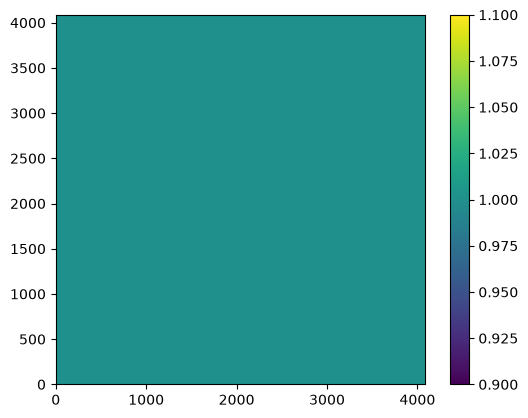

In [30]:
plt.imshow(main_offender_SCA, origin="lower")
plt.colorbar()

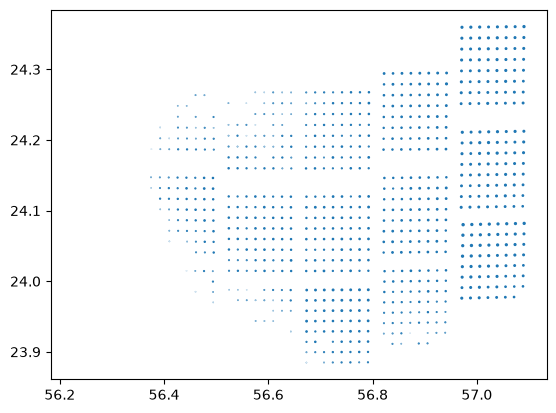

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
all_db = pd.concat(straylevel_all_SCAS)
plt.scatter(all_db["ramid"], all_db["decmid"], s=20*(np.log10(all_db["straylight_total"])-6.65))

In [4]:
all_db["straylight_total"]

0     4634551.5
1     4570982.0
2     4753398.5
3     4686550.5
4     4466265.0
        ...    
59    5385930.0
60    5563718.5
61    5489531.5
62    5598820.0
63    5721343.0
Name: straylight_total, Length: 1152, dtype: float32

In [5]:
# Benchmarking: 
# 1 - 8:30 min # Original 
# 2 - 6:45     # Using pickled Interpolators and pre calculated Rotators
# 3 - 6:30     # Pre calculating NDI conversion factor 
# 4 - 6:20     # Add all the straylight maps at the end 